# win_analytics — Prescriptor operacional por escalón del horno Ausmelt de Sn (modelo ganador v4)

**Objetivo:** recomendar, escalón a escalón, la operación de las variables de CONTROL (carbón, gas natural, O₂ y aire de
lanza) que maximiza el Sn que termina en metal crudo, a partir del ESTADO observado (leyes de escoria, inventario de Sn/FeO
por trazador CaO, temperatura, avance de reducción) y del plan del batch (mezcla de carga, cal, duración).

**Qué es el modelo ganador (v4, `modelo_predictivo_v4.py`):** un modelo *parcialmente lineal* por fase y target,
`y = g(S) + Σ θ_j·(a_j − E[a_j|S])`, con el estado `S` en un gradient boosting sin restricciones y las palancas de CONTROL
`a_j` lineales con estructura cinética (carbón × Sn disponible; carbón × avance). Los `θ_j` son el efecto de cada CONTROL
dado el estado, con IC95% por bootstrap por batch (Double ML con cross-fitting). Objetivo en kg de Sn a metal: en Reducción
`J = Sn_extraído − λ_Fe·FeO_reducido − costos − ventana térmica − soporte`; en Fusión un objetivo anclado en el KPI de batch
(carbón por Sn cargado ↓ dross; temperatura ↑ polvo).

**Cómo se llegó aquí:** iteraciones v1→v3 (`hallazgos.md` §6b-§14) y la iteración 4 (`experimentos/13-21`,
`candidate_win_model.md`), que descartó la política v3 por falta de evidencia off-policy, retiró la cal como palanca (artefacto
del trazador), descubrió que la duración de Reducción es fija por protocolo y ancló el objetivo en las regresiones de KPI de
batch. Todo el código vive en los módulos de la raíz; los experimentos pesados se leen de sus CSV (`RECALCULAR = True` los
reproduce).

Validación: OOF GroupKFold por batch sobre DEV (299 batches) para elegir; lockbox = últimos 63 batches cronológicos, sólo
para reportar.

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

import feature_engineering as fe
import modelo_prescriptivo as mp
import modelo_predictivo_v3 as mp3
import modelo_predictivo_v4 as mp4

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 60); pd.set_option("display.max_rows", 120)
EXP = Path("experimentos")
RECALCULAR = False   # True: recalcula tablas pesadas (validacion, cross-fitting) en vez de leer experimentos/21_*.csv

df = mp4.construir_dataset_modelo_v4("Datos Lingo smelter fase II.xlsx")
df_base = mp4._preparar_base(df)
batches_dev, batches_lockbox = mp.split_dev_lockbox(df)
F, R = df_base["fase_proceso"] == "Fusión", df_base["fase_proceso"] == "Reducción"
print(f"escalones modelables {df_base.shape[0]} | batches DEV {len(batches_dev)} | lockbox {len(batches_lockbox)} "
      f"| columnas seguras para prescripcion: {len(fe.filtrar_features_seguras(list(df.columns)))}")

limpiar_dataset: 2 valor(es) marcados como NaN en 2 columna(s) (detalle en el reporte devuelto).


escalones modelables 3620 | batches DEV 299 | lockbox 63 | columnas seguras para prescripcion: 137


## 1. Fundamento pirometalúrgico: qué se modela y por qué

**Batch = 7 escalones de Fusión + 4 de Reducción.** En Fusión entra concentrado (~40% Sn), reciclos, mineral de Fe, dross de Fe,
pellets, cal y carbón bajo una lanza oxidante (+19% de exceso de O₂); se forma la escoria FeO–SiO₂–CaO y ya se reduce la
mayor parte del Sn (avance ≈0.7-0.8 al fin de Fusión). En Reducción (sin carga) el carbón y la lanza sub-estequiométrica
(−5% O₂) reducen el SnOₓ residual (`SnO₂ + 2C → Sn + 2CO`) compitiendo con `FeO + C → Fe + CO`: el Fe reducido forma
hardhead/dross que arrastra Sn (canal de pérdida 1); la temperatura y el arrastre generan polvo (canal 2).

**Masa de escoria por trazador CaO** (la cal es inerte): `masa_escoria_est_kg[t] = Σ_{k≤t} feed_CaO[k] / (%CaO[t]/100)`;
`sn_inventario = masa·%Sn/100`, `feo_inventario = masa·%FeO/100`. **Targets en masa:**
`sn_extraido_est_kg[t] = feed_Sn[t] − (sn_inv[t] − sn_inv[t−1])` (Sn que dejó la escoria: a metal o a polvo) y
`feo_extraido_est_kg[t] = −(feo_inv[t] − feo_inv[t−1])` (FeO reducido: señal de sobre-reducción; sólo interpretable en
Reducción). `avance_reduccion_sn_prev = 1 − sn_inv[t−1]/Σfeed_Sn`.

**Roles.** STATE: todo lo conocido al cierre del escalón anterior (`_prev`, acumulados, inventario). CONTEXT: ensayos del
batch, refractario, posición del escalón. CONTROL (palancas del escalón): tasa de carbón, gas natural, O₂ y aire (→ exceso de
O₂ = potencial redox y aporte térmico de la lanza). PLAN (no se optimiza): mezcla de carga por tolva, cal, duración
planificada (fija por protocolo en Reducción: 30/25/20/13 min).

In [2]:
for fase in mp4.FASES:
    print(f"=== {fase} ===")
    for clave in mp4.TARGETS_V4[fase]:
        S, A = mp4.ESTADO_V4[(fase, clave)], mp4.PALANCAS_V4[(fase, clave)]
        print(f"  target {mp4.TARGETS_V4[fase][clave]:32s} | estado g(S): {len(S):2d} vars | palancas theta: {A}")
    print("  CONTROL optimizable:", mp4.ACCIONES_OPTIMIZABLES_V4[fase])
print("\nColumnas de estructura cinetica v4:", [c for c in df.columns if c.endswith('_v4')])
print("Duracion planificada en Reduccion por escalon (protocolo):")
print(df[R.reindex(df.index, fill_value=False) | (df.fase_proceso=='Reducción')].groupby('orden_escalon_fase')['duracion_plan_min'].agg(['mean','std','min','max']).round(2))

=== Fusión ===
  target sn_extraido_est_kg               | estado g(S):  9 vars | palancas theta: ['relacion_C_Sn_carga', 'relacion_CaO_carga', 'tasa_gn_nm3_min', 'exceso_o2_combustion_pct']
  target d_temperatura_horno_celsius      | estado g(S):  8 vars | palancas theta: ['tasa_gn_nm3_min', 'tasa_o2_nm3_min', 'tasa_aire_nm3_min', 'tasa_feed_Carbon_kg_min']
  CONTROL optimizable: ['tasa_feed_Carbon_kg_min', 'tasa_gn_nm3_min', 'tasa_o2_nm3_min', 'tasa_aire_nm3_min']
=== Reducción ===
  target sn_extraido_est_kg               | estado g(S): 37 vars | palancas theta: ['Cx_sn_v4', 'tasa_gn_nm3_min', 'exceso_o2_combustion_pct']
  target feo_extraido_est_kg              | estado g(S): 37 vars | palancas theta: ['tasa_feed_Carbon_kg_min', 'Cx_av_v4', 'tasa_gn_nm3_min', 'exceso_o2_combustion_pct', 'tasa_aire_nm3_min']
  target d_temperatura_horno_celsius      | estado g(S):  6 vars | palancas theta: ['tasa_gn_nm3_min', 'tasa_o2_nm3_min', 'tasa_aire_nm3_min', 'tasa_feed_Carbon_kg_min']
  CONTR

### 1.1 Formas esperadas por teoría (monótonas vs. óptimo interior)

| Variable | Rol | Efecto esperado sobre Sn extraído | Sobre FeO reducido | Forma |
|---|---|---|---|---|
| carbón | CONTROL | + (SnO₂+2C→Sn), proporcional al Sn disponible | + débil mientras hay SnOₓ, crece al agotarse | monótona (saturante) |
| exceso de O₂ (GN/O₂/aire) | CONTROL | − (atmósfera oxidante frena la reducción) | − (retiene FeO) | monótona; óptimo **interior en J** por selectividad |
| gas natural | CONTROL | + (calor + gas reductor) | + (no selectivo) | monótona; óptimo interior en J (FeO, T) |
| basicidad, lanza, temperatura | STATE | no monótona | — | sin restricción en g(S) |
| avance / inventario de Sn | STATE | + (fuerza impulsora) | − (compite) | monótona |

Los óptimos interiores del prescriptor **no se imponen**: aparecen en el objetivo `J` cuando el FeO co-reducido (selectividad
FeO/Sn pasa de 0.1 a 1.3-1.5 al superar avance 0.96, `experimentos/15`), la ventana térmica y el soporte histórico
compensan el Sn adicional.

## 2. Construcción del modelo ganador y efecto de las variables de CONTROL

`mp4.entrenar_sistema_v4` entrena, sólo con DEV, un modelo parcialmente lineal por (fase, target): `g(S)` y `E[a_j|S]` con
HistGradientBoosting (max_depth 4, 150 iteraciones, min_samples_leaf 20) y `θ` por OLS sobre residuos out-of-fold
(GroupKFold por batch, 5 folds); IC95% por bootstrap cluster por batch (300 réplicas). Además: soporte histórico kNN
(estado + palancas), límites P1-P99 de cada palanca y ventana térmica P5-P95.

In [3]:
sistema = mp4.entrenar_sistema_v4(df, n_boot=300)
efectos = mp4.tabla_efectos_control_v4(sistema)
efectos.to_csv(EXP / "win_efectos_control_v4.csv", index=False)
display(efectos[["fase", "clave", "palanca", "theta_unidad", "theta_1sd", "ci_lo_1sd", "ci_hi_1sd", "significativo", "signo_teorico", "concuerda"]].round(2))

,fase,clave,palanca,theta_unidad,theta_1sd,ci_lo_1sd,ci_hi_1sd,significativo,signo_teorico,concuerda
0,Fusión,sn_kg,relacion_C_Sn_carga,991.85,51.20,-77.27,194.69,False,1,True
1,Fusión,sn_kg,relacion_CaO_carga,-18798.78,-439.85,-720.01,-182.23,True,0,NaN
2,Fusión,sn_kg,tasa_gn_nm3_min,149.74,221.02,126.03,339.36,True,1,True
3,Fusión,sn_kg,exceso_o2_combustion_pct,29.77,81.02,-19.40,164.12,False,0,NaN
4,Fusión,dT,tasa_gn_nm3_min,-0.04,-0.06,-1.84,1.34,False,1,False
5,Fusión,dT,tasa_o2_nm3_min,-0.34,-1.12,-2.47,0.72,False,0,NaN
6,Fusión,dT,tasa_aire_nm3_min,0.14,0.73,-0.84,2.30,False,-1,False
7,Fusión,dT,tasa_feed_Carbon_kg_min,-0.02,-0.11,-1.30,0.92,False,0,NaN
8,Reducción,sn_kg,Cx_sn_v4,1.67,460.90,-44.21,904.42,False,1,True
9,Reducción,sn_kg,tasa_gn_nm3_min,16.54,81.42,22.51,144.42,True,1,True


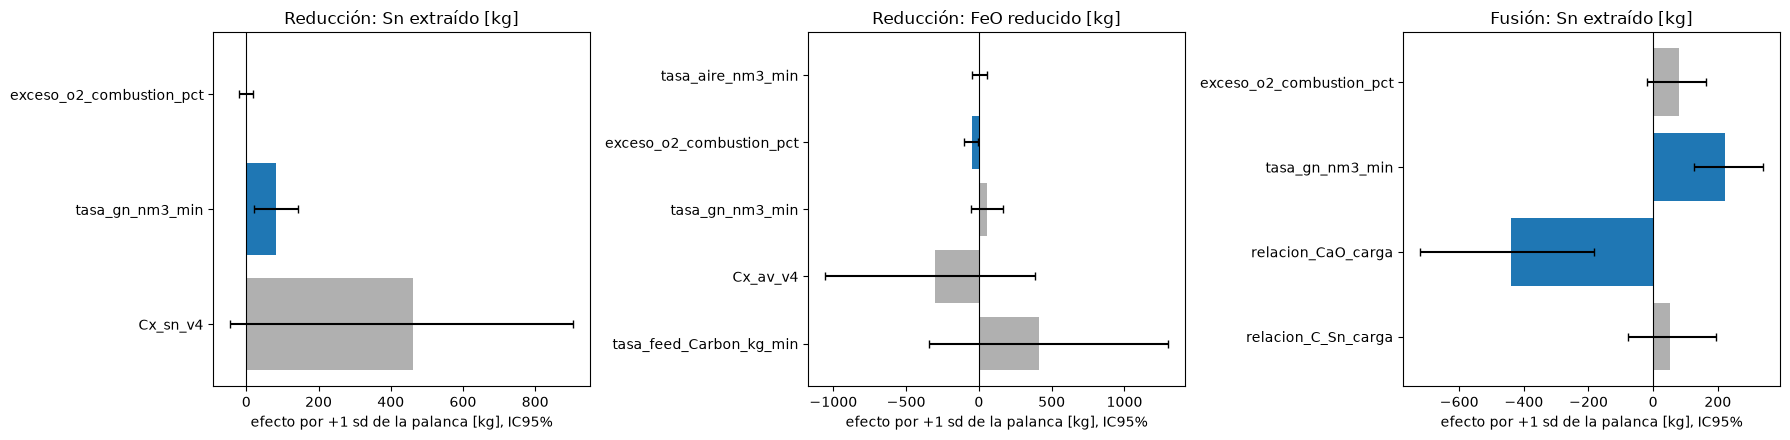

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, (fase, clave, titulo) in zip(axes, [("Reducción", "sn_kg", "Reducción: Sn extraído [kg]"), ("Reducción", "feo_kg", "Reducción: FeO reducido [kg]"), ("Fusión", "sn_kg", "Fusión: Sn extraído [kg]")]):
    e = efectos[(efectos.fase == fase) & (efectos.clave == clave)]
    y = np.arange(len(e))
    ax.barh(y, e["theta_1sd"], xerr=[e["theta_1sd"] - e["ci_lo_1sd"], e["ci_hi_1sd"] - e["theta_1sd"]], color=np.where(e["significativo"], "#1f77b4", "#b0b0b0"), capsize=3)
    ax.set_yticks(y); ax.set_yticklabels(e["palanca"]); ax.axvline(0, color="k", lw=0.8); ax.set_title(titulo); ax.set_xlabel("efecto por +1 sd de la palanca [kg], IC95%")
plt.tight_layout(); plt.show()

**Lectura.** En Reducción el gas natural sube el Sn extraído (significativo) pero también el FeO reducido (no selectivo);
el exceso de O₂ baja el FeO reducido (significativo: una lanza más oxidante retiene el FeO en la escoria); el carbón sube el
Sn con signo correcto y efecto ~0 sobre el FeO (la palanca selectiva), pero su IC cruza 0: la dosis de carbón sigue al
inventario y su efecto propio se identifica con imprecisión. En Fusión ninguna palanca química se identifica con robustez
sobre el Sn extraído (la carga domina; la cal aparece negativa pero está contaminada por el trazador, `experimentos/18`), y
por eso el objetivo de Fusión se ancla en el KPI de batch (sección 6).

## 3. Métricas de predicción (OOF GroupKFold por batch en DEV; lockbox sólo reporte)

In [5]:
tabla = mp4.tabla_validacion_v4(df) if RECALCULAR else pd.read_csv(EXP / "21_tabla_validacion_v4.csv")
display(tabla[["fase", "target", "columna", "forma", "n_estado", "n_palancas", "n_dev", "n_lockbox", "r2_oof", "mae_oof", "r2_lockbox", "mae_lockbox", "std_target_lockbox"]].round(3))
wf = pd.read_csv(EXP / "17_walkforward.csv")
print("Estabilidad temporal (experimentos/17, HGB v3 mismos targets): walk-forward cronologico en DEV")
display(wf.round(3).head(30))

,fase,target,columna,forma,n_estado,n_palancas,n_dev,n_lockbox,r2_oof,mae_oof,r2_lockbox,mae_lockbox,std_target_lockbox
0,Fusión,sn_kg,sn_extraido_est_kg,PLM_v4,9,4,1743,374,0.727,1002.802,0.726,1049.590,2941.413
1,Fusión,sn_kg,sn_extraido_est_kg,HGB_v3_ref,13,0,1743,374,0.724,1023.184,0.665,1144.960,2941.413
2,Fusión,dT,d_temperatura_horno_celsius,PLM_v4,8,4,1479,314,0.478,9.085,0.059,6.974,9.183
3,Fusión,dT,d_temperatura_horno_celsius,HGB_v3_ref,15,0,1479,314,0.469,9.231,0.015,7.197,9.183
4,Reducción,sn_kg,sn_extraido_est_kg,PLM_v4,37,3,1049,238,0.975,343.663,0.984,333.376,4386.336
5,Reducción,sn_kg,sn_extraido_est_kg,HGB_v3_ref,10,0,1049,238,0.971,372.191,0.983,358.633,4386.336
6,Reducción,feo_kg,feo_extraido_est_kg,PLM_v4,37,5,1045,242,0.357,544.005,0.378,490.192,813.970
7,Reducción,feo_kg,feo_extraido_est_kg,HGB_v3_ref,11,0,1045,242,0.288,565.661,0.321,495.616,813.970
8,Reducción,dT,d_temperatura_horno_celsius,PLM_v4,6,4,1181,252,0.474,9.155,0.427,6.587,11.299
9,Reducción,dT,d_temperatura_horno_celsius,HGB_v3_ref,14,0,1181,252,0.452,9.302,0.294,7.205,11.299


Estabilidad temporal (experimentos/17, HGB v3 mismos targets): walk-forward cronologico en DEV


,fase,target,bloque,tipo,n_train,n_test,batch_ini_test,batch_fin_test,r2,mae
0,Fusión,sn_kg,0,walkforward_bloque,315.0,292.0,AP0054,AP0102,0.671,1099.371
1,Fusión,sn_kg,1,walkforward_bloque,607.0,293.0,AP0103,AP0151,0.734,989.455
2,Fusión,sn_kg,2,walkforward_bloque,900.0,287.0,AP0152,AP0200,0.697,1085.301
3,Fusión,sn_kg,3,walkforward_bloque,1187.0,277.0,AP0201,AP0250,0.708,1191.494
4,Fusión,sn_kg,4,walkforward_bloque,1464.0,285.0,AP0251,AP0299,0.631,1354.487
5,Fusión,sn_kg,global_walkforward,walkforward_global,NaN,1434.0,NaN,NaN,0.688,1142.595
6,Fusión,sn_kg,global_oof_aleatorio,oof_aleatorio,NaN,1749.0,NaN,NaN,0.722,1036.797
7,Fusión,sn_kg,brecha (aleatorio - walkforward),brecha,NaN,NaN,NaN,NaN,0.034,105.798
8,Reducción,sn_kg,0,walkforward_bloque,191.0,178.0,AP0054,AP0102,0.953,535.822
9,Reducción,sn_kg,1,walkforward_bloque,369.0,171.0,AP0103,AP0151,0.982,316.098


En Reducción el modelo de Sn es excelente (R² ≈0.97 OOF / 0.98 lockbox) porque la extracción es casi determinista dado el
inventario (una regla física trivial "inventario × fracción media por escalón" ya da 0.97, `experimentos/18`): el valor del
modelo no está en el R² sino en los `θ` de las palancas. El FeO reducido es intrínsecamente ruidoso (techo de ruido del
trazador R²_max ≈0.68; `experimentos/15`). En Fusión el Sn extraído lo explica la carga (R² ≈0.73 / 0.69).

## 4. Real vs. predicho (scatter y evolutivo)

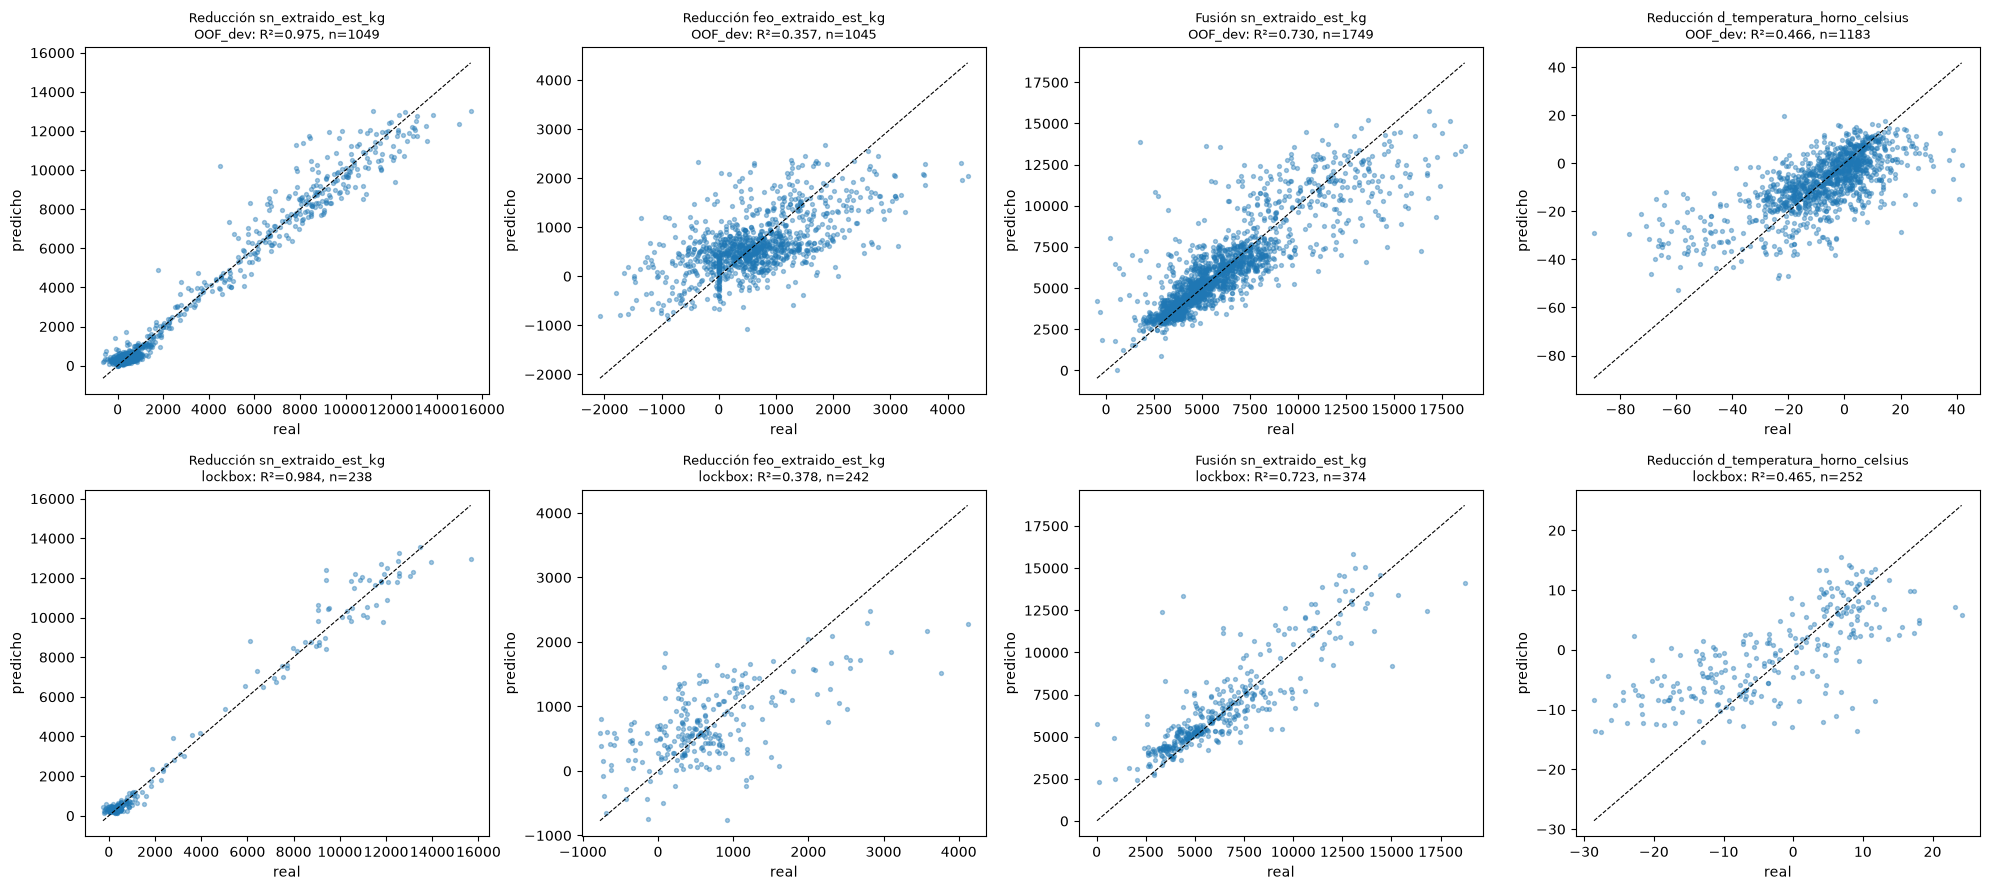

In [6]:
def cargar_pred(fase, clave):
    return mp4.predicciones_oof_y_lockbox_v4(df, fase, clave) if RECALCULAR else pd.read_csv(EXP / f"21_pred_oof_lockbox_{fase}_{clave}.csv", parse_dates=["fecha_inicio"])

combos = [("Reducción", "sn_kg"), ("Reducción", "feo_kg"), ("Fusión", "sn_kg"), ("Reducción", "dT")]
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for j, (fase, clave) in enumerate(combos):
    p = cargar_pred(fase, clave)
    for i, conjunto in enumerate(["OOF_dev", "lockbox"]):
        q = p[p.conjunto == conjunto]; ax = axes[i, j]
        ax.scatter(q.real, q.pred, s=8, alpha=0.4)
        lim = [min(q.real.min(), q.pred.min()), max(q.real.max(), q.pred.max())]; ax.plot(lim, lim, "k--", lw=0.8)
        r2 = 1 - ((q.real - q.pred) ** 2).sum() / ((q.real - q.real.mean()) ** 2).sum()
        ax.set_title(f"{fase} {mp4.TARGETS_V4[fase][clave]}\n{conjunto}: R²={r2:.3f}, n={len(q)}", fontsize=9)
        ax.set_xlabel("real"); ax.set_ylabel("predicho")
plt.tight_layout(); plt.show()

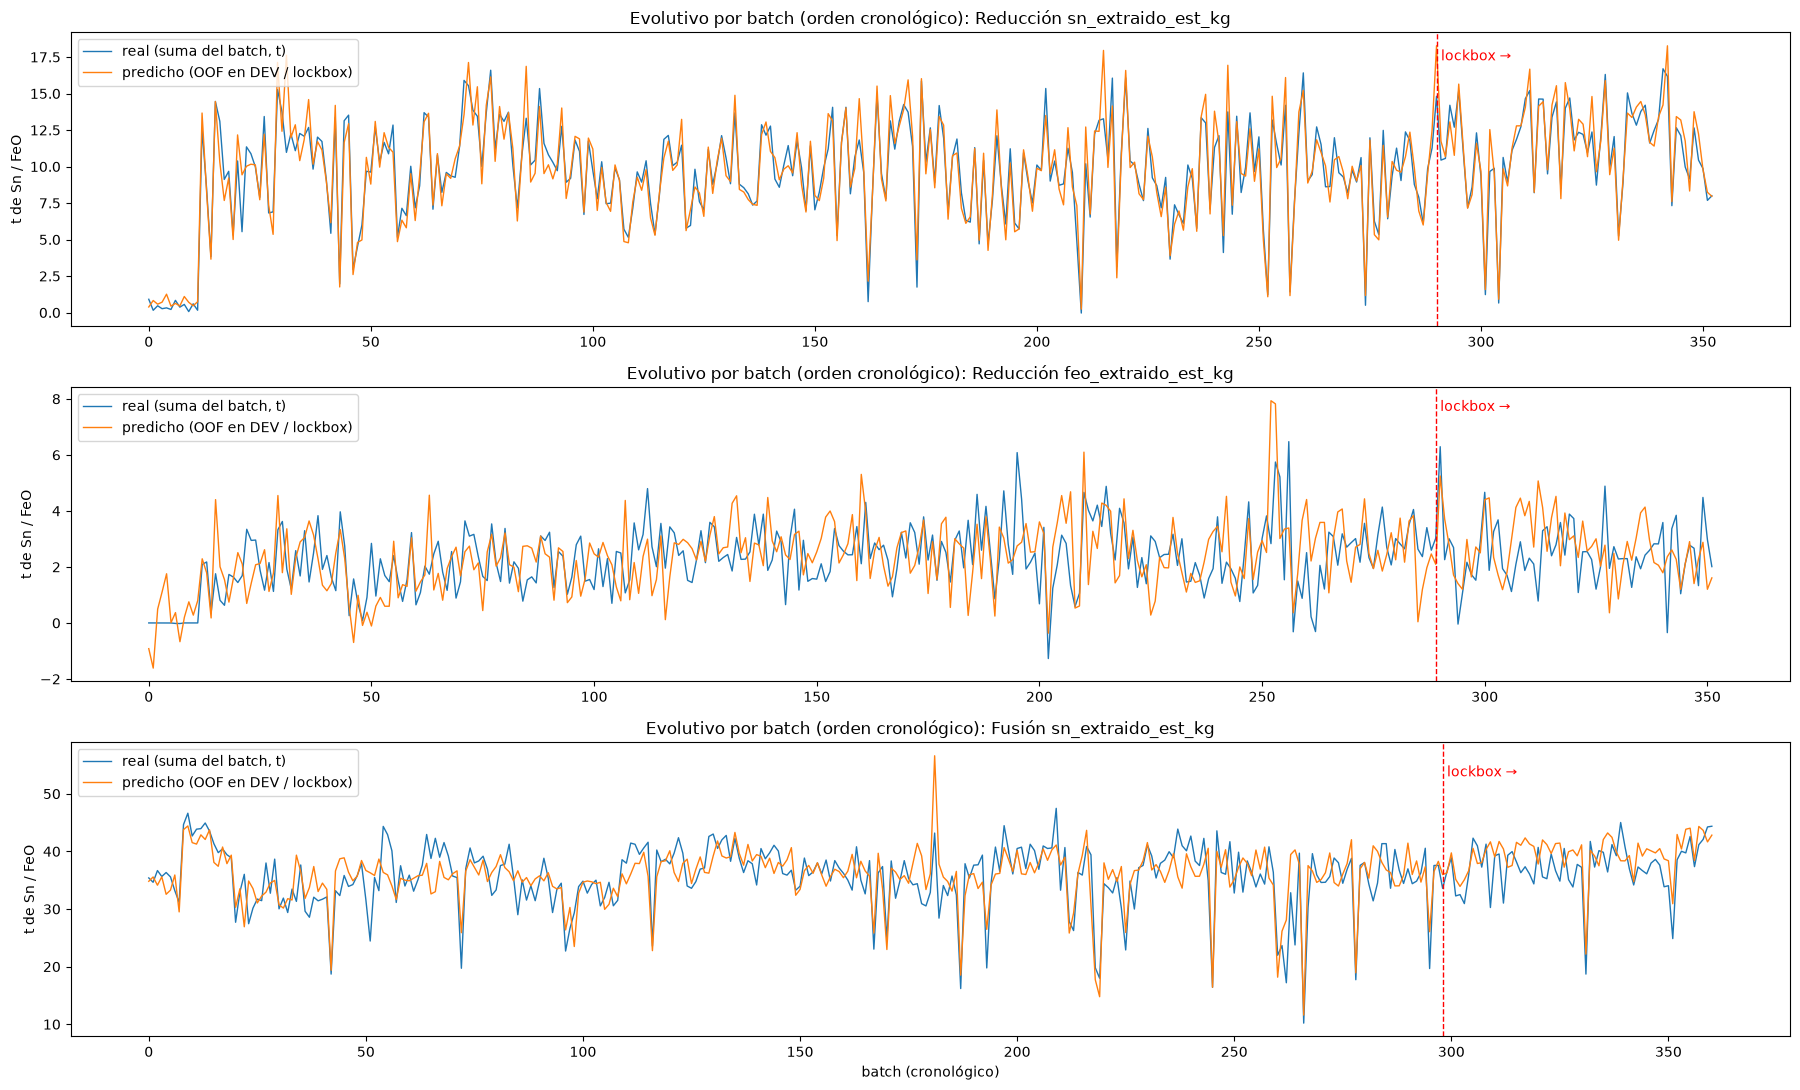

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(18, 11))
for ax, (fase, clave) in zip(axes, [("Reducción", "sn_kg"), ("Reducción", "feo_kg"), ("Fusión", "sn_kg")]):
    p = cargar_pred(fase, clave)
    b = p.groupby("Batch").agg(fecha=("fecha_inicio", "min"), real=("real", "sum"), pred=("pred", "sum"), conjunto=("conjunto", "first")).sort_values("fecha")
    x = np.arange(len(b))
    ax.plot(x, b.real / 1000, label="real (suma del batch, t)", lw=1)
    ax.plot(x, b.pred / 1000, label="predicho (OOF en DEV / lockbox)", lw=1)
    i0 = int((b.conjunto == "OOF_dev").sum()); ax.axvline(i0, color="r", ls="--", lw=1); ax.text(i0 + 1, ax.get_ylim()[1] * 0.9 if ax.get_ylim()[1] > 0 else 0, "lockbox →", color="r")
    ax.set_title(f"Evolutivo por batch (orden cronológico): {fase} {mp4.TARGETS_V4[fase][clave]}"); ax.set_ylabel("t de Sn / FeO"); ax.legend(loc="upper left")
axes[-1].set_xlabel("batch (cronológico)")
plt.tight_layout(); plt.show()

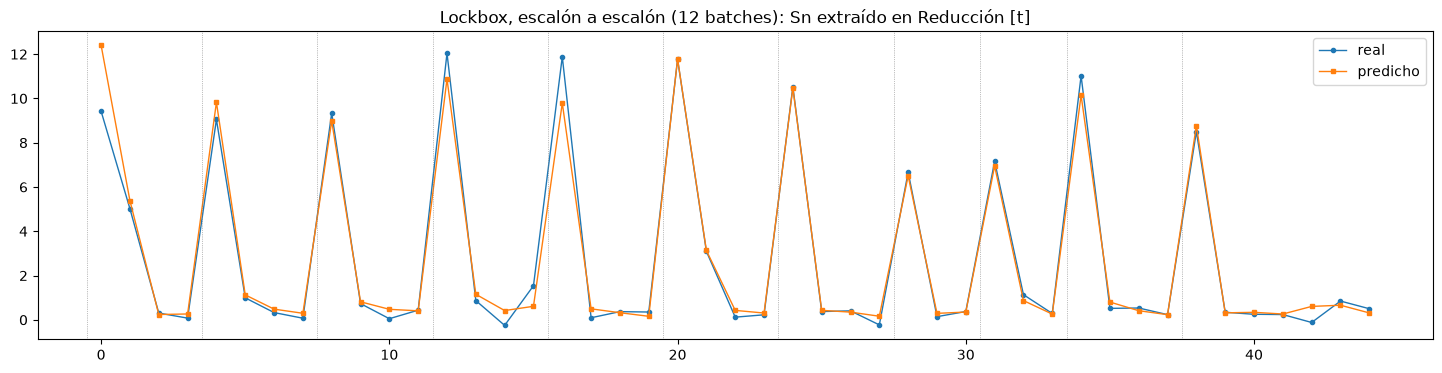

In [8]:
# Evolutivo a nivel de escalon en el lockbox (primeros 12 batches): Reduccion, Sn extraido
p = cargar_pred("Reducción", "sn_kg"); q = p[p.conjunto == "lockbox"].sort_values(["fecha_inicio"])
q = q[q.Batch.isin(sorted(q.Batch.unique())[:12])].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(q.real / 1000, "o-", ms=3, lw=1, label="real"); ax.plot(q.pred / 1000, "s-", ms=3, lw=1, label="predicho")
for i in np.where(q.orden_escalon_fase == 0)[0]:
    ax.axvline(i - 0.5, color="grey", lw=0.5, ls=":")
ax.set_title("Lockbox, escalón a escalón (12 batches): Sn extraído en Reducción [t]"); ax.legend(); plt.show()

## 5. Interpretabilidad: SHAP del estado, respuesta a las palancas y formas aprendidas vs. teoría

El PLM separa el efecto del ESTADO (no lineal, `g(S)`, interpretado con SHAP) del efecto de las palancas de CONTROL (lineal,
`θ`, interpretado directamente). Las curvas de respuesta del prescriptor (predicción y `J` a lo largo de cada palanca en un
estado concreto) son la dependencia parcial operativa.

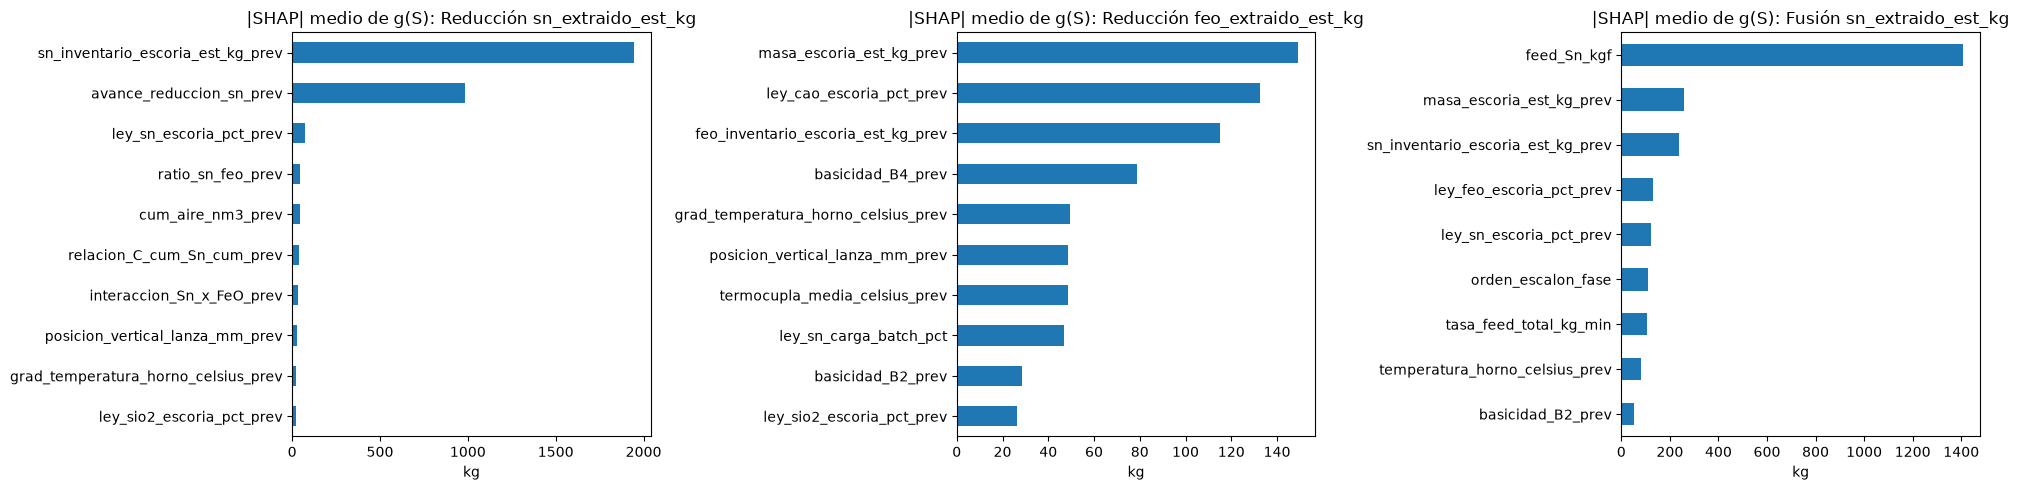

In [9]:
import shap
def shap_estado(fase, clave, n=600, top=8):
    m = sistema.modelos[(fase, clave)]
    d = df_base[(df_base.fase_proceso == fase) & df_base.Batch.isin(batches_dev)].dropna(subset=m.estado + [m.target]).sample(min(n, 5000), random_state=0)
    X = d[m.estado]
    sv = shap.TreeExplainer(m.g).shap_values(X)
    imp = pd.Series(np.abs(sv).mean(axis=0), index=m.estado).sort_values(ascending=False)
    return X, sv, imp

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (fase, clave) in zip(axes, [("Reducción", "sn_kg"), ("Reducción", "feo_kg"), ("Fusión", "sn_kg")]):
    X, sv, imp = shap_estado(fase, clave)
    imp.head(10)[::-1].plot.barh(ax=ax); ax.set_title(f"|SHAP| medio de g(S): {fase} {mp4.TARGETS_V4[fase][clave]}"); ax.set_xlabel("kg")
plt.tight_layout(); plt.show()

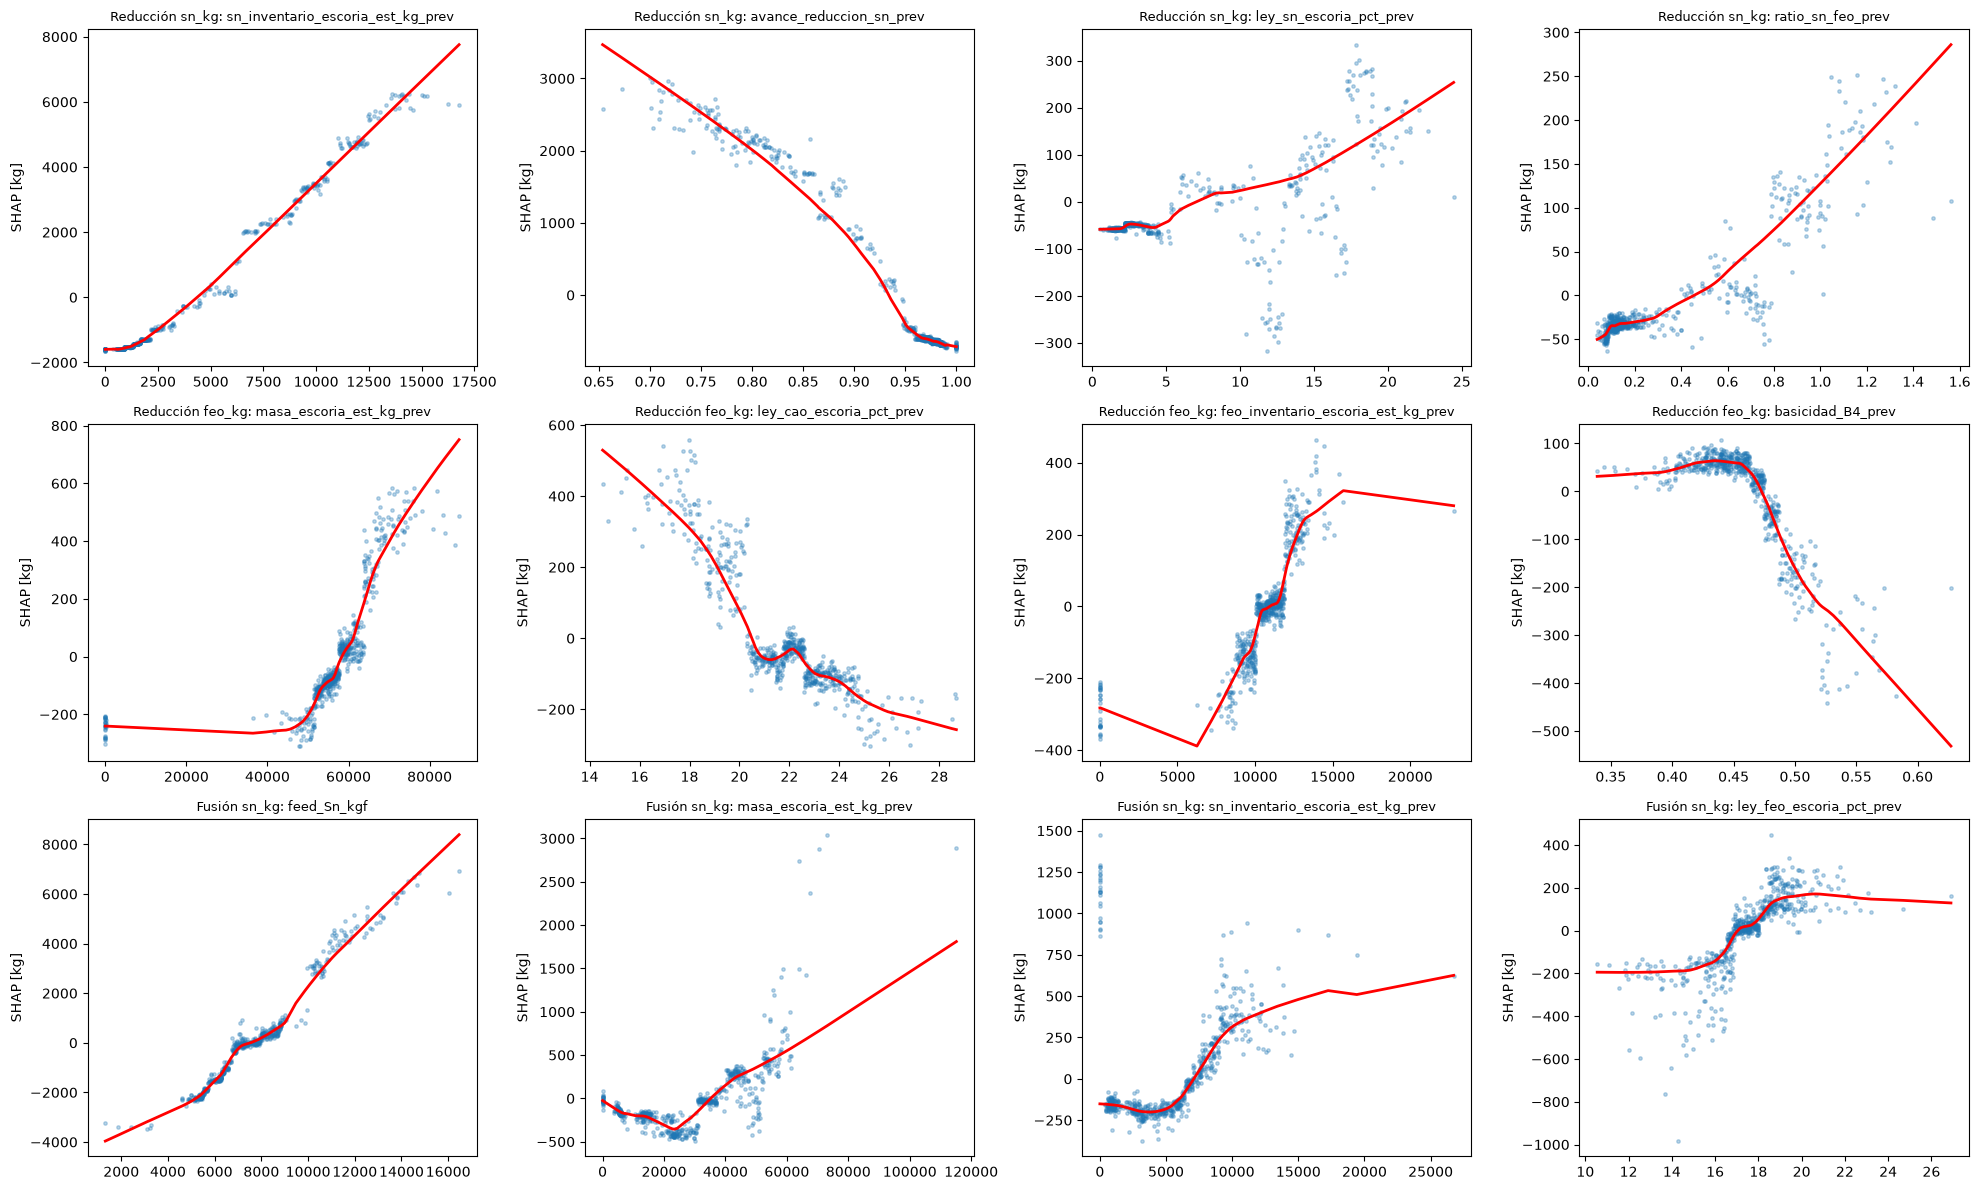

In [10]:
# Dependencia SHAP (estado) de las 4 variables mas importantes por modelo, con LOWESS
from statsmodels.nonparametric.smoothers_lowess import lowess
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for i, (fase, clave) in enumerate([("Reducción", "sn_kg"), ("Reducción", "feo_kg"), ("Fusión", "sn_kg")]):
    X, sv, imp = shap_estado(fase, clave)
    for j, f in enumerate(imp.index[:4]):
        ax = axes[i, j]; k = list(X.columns).index(f)
        ax.scatter(X[f], sv[:, k], s=6, alpha=0.3)
        ok = X[f].notna().to_numpy()
        lw = lowess(sv[ok, k], X[f].to_numpy()[ok], frac=0.3, return_sorted=True); ax.plot(lw[:, 0], lw[:, 1], "r-", lw=2)
        ax.set_title(f"{fase} {clave}: {f}", fontsize=9); ax.set_ylabel("SHAP [kg]")
plt.tight_layout(); plt.show()

In [11]:
# Formas aprendidas vs teoria (experimentos/16, HGB v3 sin PLM): resumen para CONTROL y STATE clave
formas = pd.read_csv(EXP / "16_formas_pd.csv")
clave_feats = ["tasa_feed_Carbon_kg_min", "interaccion_C_x_Sn_prev", "tasa_gn_nm3_min", "exceso_o2_combustion_pct", "relacion_CaO_carga", "tasa_feed_CaO_kg_min",
               "basicidad_B2_prev", "temperatura_horno_celsius_prev", "posicion_vertical_lanza_mm_prev", "avance_reduccion_sn_prev", "sn_inventario_escoria_est_kg_prev", "ley_feo_escoria_pct_prev"]
display(formas[formas.feature.isin(clave_feats) & formas.modelo.str.contains("default|pool")][["modelo", "feature", "rol", "rango_rel_sd", "forma", "x_extremo", "tipo_teorico", "concuerda"]].round(3))

,modelo,feature,rol,rango_rel_sd,forma,x_extremo,tipo_teorico,concuerda
1,Fusión_sn_kg_default,sn_inventario_escoria_est_kg_prev,STATE,0.169,óptimo interior (mínimo),1271.144,mono+,no
5,Fusión_sn_kg_default,interaccion_C_x_Sn_prev,DERIVED_CONTROL,0.175,monótona +,958.074,mono+_debil,sí
6,Fusión_sn_kg_default,tasa_feed_Carbon_kg_min,CONTROL,0.084,monótona +,62.790,mono+_debil,sí
7,Fusión_sn_kg_default,relacion_CaO_carga,DERIVED_CONTROL,0.174,óptimo interior (mínimo),0.104,mono-,parcial
8,Fusión_sn_kg_default,tasa_gn_nm3_min,CONTROL,0.200,óptimo interior (mínimo),30.457,mono+_sat,no
9,Fusión_sn_kg_default,exceso_o2_combustion_pct,DERIVED_CONTROL,0.079,óptimo interior (máximo),19.181,sin_restriccion,NaN
10,Fusión_sn_kg_default,basicidad_B2_prev,STATE,0.134,óptimo interior (mínimo),0.496,optimo_interior,sí
11,Fusión_sn_kg_default,temperatura_horno_celsius_prev,STATE,0.077,óptimo interior (mínimo),1135.019,mono+,no
27,Fusión_sn_kg_pool_amplio,sn_inventario_escoria_est_kg_prev,STATE,0.294,no monótona compleja,18869.340,mono+,parcial
31,Fusión_sn_kg_pool_amplio,interaccion_C_x_Sn_prev,DERIVED_CONTROL,0.177,monótona +,1083.595,mono+_debil,sí


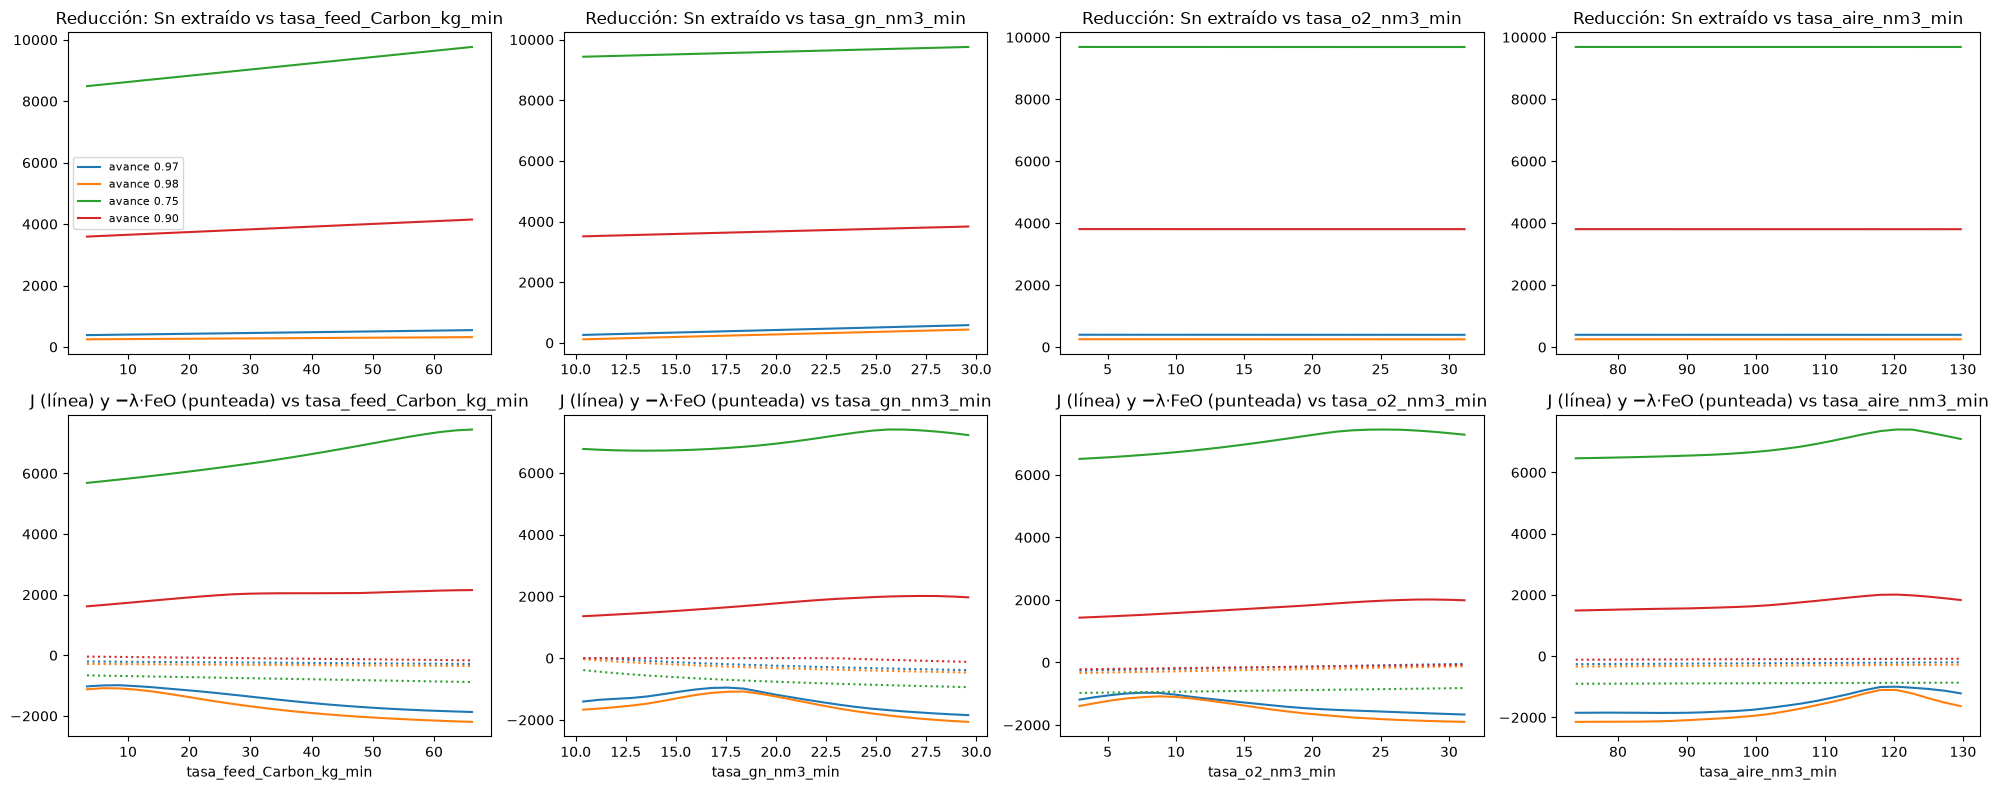

x_hist_min   x_opt   x_max  rango_J_kg
fase      Batch  avance_prev palanca                                                        
Fusión    AP0174 0.694829    tasa_aire_nm3_min             96.90  119.96  124.57     1026.76
                             tasa_feed_Carbon_kg_min       24.33   64.11   64.11     1562.88
                             tasa_gn_nm3_min               24.46   30.17   32.07      927.63
                             tasa_o2_nm3_min               33.96   46.86   51.15      877.51
                 0.739293    tasa_aire_nm3_min             96.90  119.96  124.57      678.25
                             tasa_feed_Carbon_kg_min       24.33   64.11   64.11     1154.96
                             tasa_gn_nm3_min               24.46   30.80   32.07      584.14
                             tasa_o2_nm3_min               33.96   48.29   51.15      618.97
                 0.785821    tasa_aire_nm3_min             96.90  119.96  124.57      818.02
                             tasa_feed_Carbon_kg_min       24.33   60.80   64.11      455.26
                             tasa_gn_nm3_min               24.46   30.17   32.07      751.87
                             tasa_o2_nm3_min               33.96   46.14   51.15      717.04
Reducción AP0021 0.965029    tasa_aire_nm3_min             73.88  120.39  129.69      856.08
                             tasa_feed_Carbon_kg_min        3.29    8.54   66.21      883.02
                             tasa_gn_nm3_min               10.38   17.59   29.60      891.58
                             tasa_o2_nm3_min                2.94    7.64   31.14      697.37
          AP0031 0.984996    tasa_aire_nm3_min             73.88  118.06  129.69     1043.76
                             tasa_feed_Carbon_kg_min        3.29    5.92   66.21     1111.28
                             tasa_gn_nm3_min               10.38   18.39   29.60      984.33
                             tasa_o2_nm3_min                2.94    8.81   31.14      817.39
          AP0044 0.749468    tasa_aire_nm3_min             73.88  120.39  129.69      940.07
                             tasa_feed_Carbon_kg_min        3.29   66.21   66.21     1760.13
                             tasa_gn_nm3_min               10.38   25.60   29.60      685.52
                             tasa_o2_nm3_min                2.94   25.27   31.14      940.71
          AP0247 0.899789    tasa_aire_nm3_min             73.88  120.39  129.69      519.53
                             tasa_feed_Carbon_kg_min        3.29   66.21   66.21      536.24
                             tasa_gn_nm3_min               10.38   27.20   29.60      656.67
                             tasa_o2_nm3_min                2.94   28.79   31.14      580.56

In [12]:
# Curvas de respuesta del prescriptor (experimentos/21): prediccion y J a lo largo de cada palanca, en estados representativos
cur = pd.read_csv(EXP / "21_curvas_respuesta_v4.csv")
red = cur[cur.fase == "Reducción"]
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for j, pal in enumerate(mp4.ACCIONES_OPTIMIZABLES_V4["Reducción"]):
    for (b, av), g in red[red.palanca == pal].groupby(["Batch", "avance_prev"]):
        axes[0, j].plot(g.valor, g.pred_sn_extraido_kg, label=f"avance {av:.2f}"); axes[1, j].plot(g.valor, g.J, label=f"avance {av:.2f}")
        axes[1, j].plot(g.valor, g.pred_feo_reducido_kg * -mp4.LAMBDA_FE_KG_SN_POR_KG_FEO, ls=":", color=axes[1, j].lines[-1].get_color())
    axes[0, j].set_title(f"Reducción: Sn extraído vs {pal}"); axes[1, j].set_title(f"J (línea) y −λ·FeO (punteada) vs {pal}"); axes[1, j].set_xlabel(pal)
axes[0, 0].legend(fontsize=8); plt.tight_layout(); plt.show()
opt = cur.groupby(["fase", "Batch", "avance_prev", "palanca"]).apply(lambda g: pd.Series({"x_hist_min": g.valor.min(), "x_opt": g.loc[g.J.idxmax(), "valor"], "x_max": g.valor.max(), "rango_J_kg": g.J.max() - g.J.min()})).round(2)
display(opt)

**Lectura.** El Sn extraído responde de forma monótona a cada palanca (por construcción, con pendiente `θ`), pero `J` no:
el FeO co-reducido (`−λ·FeO`), la ventana térmica y el soporte histórico producen máximos interiores o en el borde del
soporte según el estado (avance de reducción). Las recomendaciones nunca salen del envolvente histórico (soporte mínimo duro
= P10 de DEV).

## 6. Capa prescriptiva: objetivo, roles y recomendación por escalón

- **Reducción:** `J_R = Sn_extraído − λ_Fe·FeO_reducido − costos(C, GN, O₂) − w_T·(T fuera de P5-P95) − w_U·ancho_IC − w_S·(1−soporte)`,
  con `λ_Fe = 0.60` kg de Sn a metal perdidos por kg de FeO reducido (canales dross + polvo: `f_metal ~ −0.0139/sd de FeO_R`,
  p=0.013, `experimentos/19`; sólo dross: 0.30-0.32, `experimentos/15`).
- **Fusión:** `J_F = β_C·z(C/Sn cargado) − β_T·z(T predicha) − costos − w_U·ancho_IC(ΔT) − w_S·(1−soporte)`, con
  `β_C = 0.0087·f_dross/sd` (p=0.011) y `β_T = 0.0129·f_polvo/sd` (p=0.027), convertidos a kg de Sn por escalón
  (51.25 t de Sn de salida por batch / 7 escalones).
- **Palancas:** carbón, GN, O₂, aire (búsqueda aleatoria en P1-P99 + refinamiento local; la acción histórica siempre es
  candidata; soporte mínimo duro). El resto (carga, cal, duración) es plan.

In [13]:
batch = sorted(batches_lockbox)[0]
rep = mp4.reporte_recomendaciones_batch_v4(sistema, df, batch, n_candidatos=300)
res = mp4.resumen_reporte_batch_v4(rep)
print({k: round(v, 1) if isinstance(v, float) else v for k, v in res.items()})
cols = ["fase", "orden_escalon_fase", "avance_reduccion_sn_prev", "pred_sn_kg_historico", "pred_sn_kg_recomendado", "pred_feo_reducido_kg_historico", "pred_feo_reducido_kg_recomendado",
        "pred_T_historico", "pred_T_recomendado", "support_historico", "support_recomendado", "uplift_J_kgSn"] + [c for c in rep.columns if c.startswith("hist__tasa_feed_Carbon") or c.startswith("rec__tasa_feed_Carbon") or c.endswith("gn_nm3_min") or c.endswith("o2_nm3_min") or c.endswith("aire_nm3_min")]
display(rep[cols].round(2).T)

{'n_escalones': 10, 'uplift_fisico_fusion_kg': 1048.4, 'uplift_fisico_reduccion_kg': 181.6, 'uplift_fisico_total_kg': 1230.0, 'uplift_J_fusion_kg': 1460.5, 'uplift_J_reduccion_kg': 623.7, 'uplift_J_total_kg': 2084.2, 'reduccion_sn_extraido_adicional_kg': 327.1, 'reduccion_feo_reducido_adicional_kg': 214.1, 'pct_escalones_con_mejora': 90.0, 'support_medio_historico': 0.3, 'support_medio_recomendado': 0.4}


,0,1,2,3,4,5,6,7,8,9
fase,Fusión,Fusión,Fusión,Fusión,Fusión,Fusión,Reducción,Reducción,Reducción,Reducción
orden_escalon_fase,1,2,3,4,5,6,0,1,2,3
avance_reduccion_sn_prev,0.92,0.66,0.64,0.67,0.71,0.69,0.72,0.88,0.97,0.98
pred_sn_kg_historico,3606.04,4821.08,5032.04,6293.74,7410.03,8226.69,12396.28,5376.34,239.69,264.26
pred_sn_kg_recomendado,3618.0,4848.07,5012.56,6350.58,7320.38,8178.41,12510.54,5376.34,385.58,331.2
pred_feo_reducido_kg_historico,NaN,NaN,NaN,NaN,NaN,NaN,1358.72,953.27,0.0,214.55
pred_feo_reducido_kg_recomendado,NaN,NaN,NaN,NaN,NaN,NaN,1438.32,953.27,0.0,349.02
pred_T_historico,1038.25,1023.75,1036.95,1021.89,1024.45,1029.39,1009.41,980.82,962.79,952.51
pred_T_recomendado,1038.11,1023.5,1037.21,1022.04,1024.72,1029.69,1010.77,980.82,967.17,954.04
support_historico,0.31,0.44,0.36,0.4,0.45,0.33,0.3,0.16,0.23,0.39


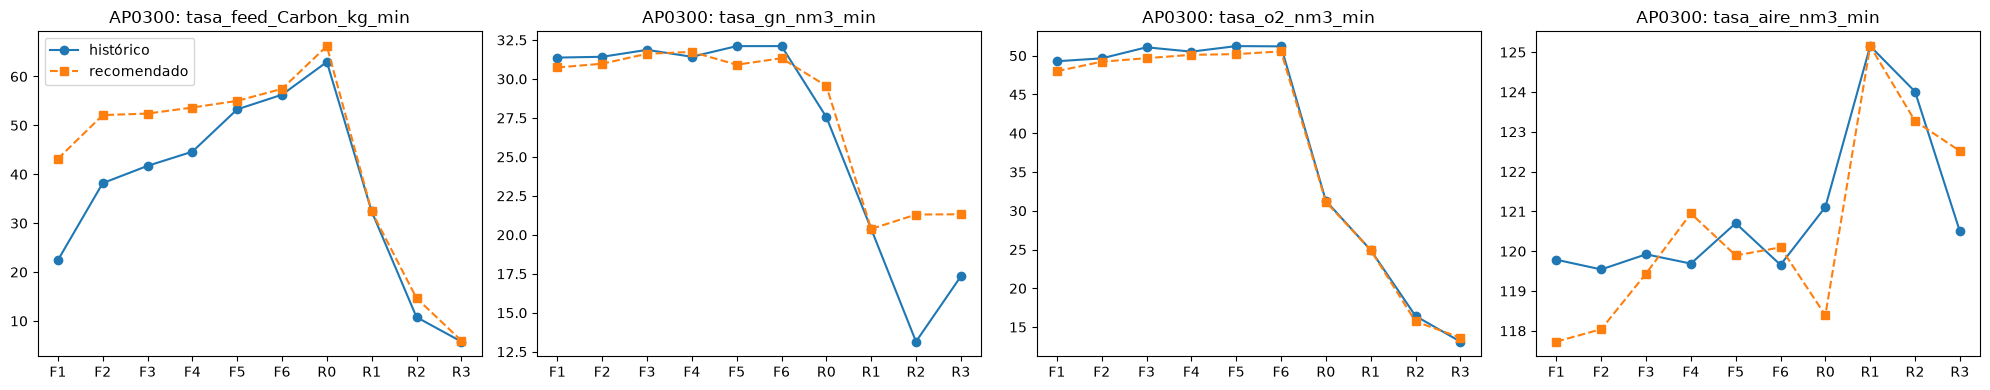

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, pal in zip(axes, mp4.ACCIONES_OPTIMIZABLES_V4["Reducción"]):
    x = np.arange(len(rep)); ax.plot(x, rep[f"hist__{pal}"], "o-", label="histórico"); ax.plot(x, rep[f"rec__{pal}"], "s--", label="recomendado")
    ax.set_xticks(x); ax.set_xticklabels([f"{f[0]}{o}" for f, o in zip(rep.fase, rep.orden_escalon_fase)]); ax.set_title(f"{batch}: {pal}")
axes[0].legend(); plt.tight_layout(); plt.show()

## 7. Sustento: ¿aplicar las recomendaciones conduce a mayor rendimiento proxy del batch?

Tres capas de evidencia, todas con controles de contexto (ley del concentrado, refractario, Sn cargado, temperatura de
Fusión, carga secundaria) y separando DEV (estimación) de lockbox (comprobación):

1. **Mecanismo escalón → batch** (`experimentos/15` y `19`): el FeO reducido en Reducción baja la fracción a metal y sube dross
   y polvo (λ_Fe); la selectividad FeO/Sn se degrada ~10× al superar avance 0.96.
2. **Decisiones por fase vs. canales de pérdida del batch** (`experimentos/19`, OLS HC3, coeficiente por +1 sd): las mismas
   direcciones que recomienda el prescriptor.
3. **Evidencia off-policy cross-fitted** (`experimentos/21`): cada batch recibe la recomendación de un sistema que nunca lo
   vio; la distancia entre la operación real y la recomendada se relaciona con el rendimiento observado (con placebo de
   política aleatoria y p de permutación).

kpi                           f_dross                 f_metal                 f_polvo                
muestra                           dev lockbox   total     dev lockbox   total     dev lockbox   total
variable         modelo                                                                              
C_por_Sn_F       M1_Fusion    -0.0087 -0.0005 -0.0097  0.0037 -0.0046  0.0051  0.0050  0.0051  0.0046
F_avance_final   M4_Mecanismo  0.0070  0.0021  0.0084 -0.0059 -0.0088 -0.0069 -0.0011  0.0067 -0.0014
FeO_reducido_R_t M4_Mecanismo  0.0065 -0.0206  0.0047 -0.0139  0.0086 -0.0118  0.0074  0.0120  0.0072
T_media_F        M1_Fusion    -0.0039  0.0406 -0.0064 -0.0090 -0.0928 -0.0091  0.0129  0.0522  0.0156
T_media_R        M2_Reduccion -0.0040  0.0045 -0.0034 -0.0028 -0.0297 -0.0047  0.0068  0.0252  0.0082
carbon_total_R   M2_Reduccion -0.0063  0.1385 -0.0041  0.0041 -0.0891  0.0048  0.0023 -0.0493 -0.0008
exceso_o2_R      M2_Reduccion  0.0024  0.0039  0.0022 -0.0050 -0.0050 -0.0039  0.0026  0.0010  0.0016
gn_total_R       M2_Reduccion  0.0076  0.0061  0.0073 -0.0104  0.0051 -0.0079  0.0028 -0.0111  0.0007

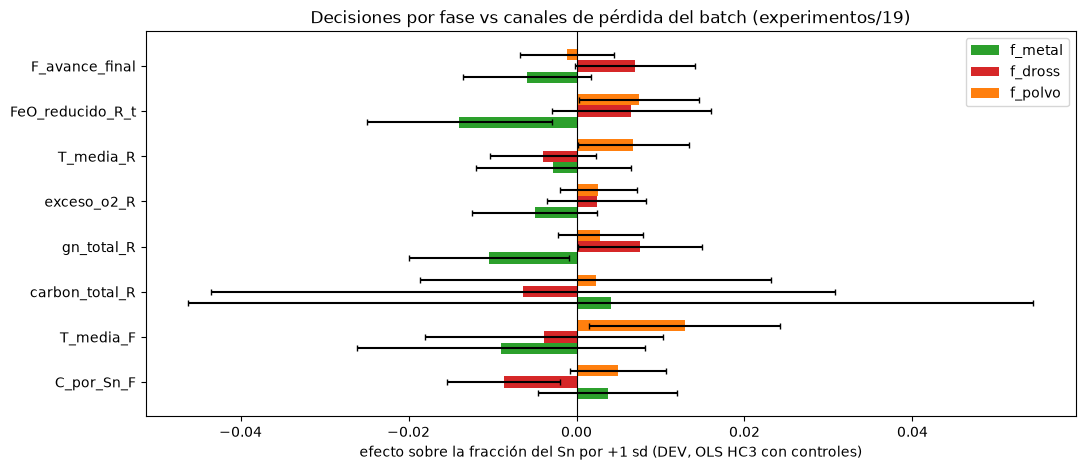

,variante,n,variable,coef,se,ci_lo,ci_hi,pvalue,r2
0,a_crudo_simple,338,FeO_total_R_t,0.300,0.108,0.088,0.512,0.006,0.022
1,a_crudo_controles,338,FeO_total_R_t,0.322,0.110,0.107,0.537,0.003,0.114
7,b_suavizado_simple,338,FeO_total_R_suav_t,0.422,0.112,0.202,0.642,0.000,0.033
8,b_suavizado_controles,338,FeO_total_R_suav_t,0.435,0.110,0.219,0.651,0.000,0.124
14,c_R01_R23_simple,338,FeO_R01_t,0.344,0.117,0.115,0.573,0.003,0.024
15,c_R01_R23_simple,338,FeO_R23_t,0.182,0.178,-0.166,0.530,0.305,0.024
16,c_R01_R23_simple,338,FeO_R23_t - FeO_R01_t = 0,-0.162,0.184,-0.522,0.198,0.378,0.024
17,c_R01_R23_controles,338,FeO_R01_t,0.380,0.118,0.149,0.610,0.001,0.118
18,c_R01_R23_controles,338,FeO_R23_t,0.170,0.179,-0.181,0.522,0.342,0.118
24,c_R01_R23_controles,338,FeO_R23_t - FeO_R01_t = 0,-0.209,0.185,-0.571,0.152,0.257,0.118


,bin,n,avance_min,avance_max,avance_medio,pendiente_feo_por_sn,ci_lo,ci_hi,pvalue,r2
0,0,260,0.609,0.837,0.772,0.111,0.041,0.182,0.002,0.042
1,1,260,0.838,0.964,0.923,0.170,0.119,0.222,0.000,0.158
2,2,260,0.964,0.975,0.970,1.552,1.241,1.864,0.000,0.342
3,3,260,0.975,0.980,0.978,1.260,0.909,1.611,0.000,0.207
4,4,260,0.981,1.000,0.987,0.989,0.533,1.444,0.000,0.176


In [15]:
reg = pd.read_csv(EXP / "19_regresiones_kpi.csv")
vars_pol = ["C_por_Sn_F", "T_media_F", "carbon_total_R", "gn_total_R", "exceso_o2_R", "T_media_R", "FeO_reducido_R_t", "F_avance_final"]
sel = reg[reg.variable.isin(vars_pol) & reg.modelo.str.contains("M1|M2|M4") & reg.kpi.isin(["f_metal", "f_dross", "f_polvo"])]
piv = sel.pivot_table(index=["variable", "modelo"], columns=["kpi", "muestra"], values="coef_por_sd").round(4)
display(piv)
fig, ax = plt.subplots(figsize=(12, 5))
d = sel[(sel.muestra.str.upper() == "DEV")]
for k, (kpi, col) in enumerate([("f_metal", "#2ca02c"), ("f_dross", "#d62728"), ("f_polvo", "#ff7f0e")]):
    q = d[d.kpi == kpi].drop_duplicates("variable").set_index("variable").reindex(vars_pol)
    y = np.arange(len(vars_pol)) + (k - 1) * 0.25
    ax.barh(y, q.coef_por_sd, height=0.25, xerr=[q.coef_por_sd - q.ci_lo, q.ci_hi - q.coef_por_sd], color=col, label=kpi, capsize=2)
ax.set_yticks(np.arange(len(vars_pol))); ax.set_yticklabels(vars_pol); ax.axvline(0, color="k", lw=0.8); ax.legend(); ax.set_xlabel("efecto sobre la fracción del Sn por +1 sd (DEV, OLS HC3 con controles)")
ax.set_title("Decisiones por fase vs canales de pérdida del batch (experimentos/19)"); plt.show()
lam = pd.read_csv(EXP / "15_lambda_fe.csv"); display(lam[lam.variable.str.startswith("FeO")].round(3))
sel15 = pd.read_csv(EXP / "15_selectividad_marginal.csv"); display(sel15.round(3))

,subset,kpi,variable,n,coef_por_sd,ci_lo,ci_hi,p_hc3,p_perm,spearman,p_spearman,r2_adj
0,DEV,rendimiento_proxy_batch,dist_total,298,0.2568,-0.1902,0.7039,0.2601,0.360,0.0051,0.9308,-0.0006
1,DEV,rendimiento_proxy_batch,dist_F,297,-0.1117,-0.6102,0.3868,0.6604,0.692,0.0154,0.7911,-0.0028
2,DEV,rendimiento_proxy_batch,dist_R,298,0.3317,-0.0317,0.6951,0.0737,0.242,0.0086,0.8820,0.0016
3,DEV,rendimiento_proxy_batch,uplift_fisico_total_kg,298,0.3964,-0.1167,0.9096,0.1300,0.122,0.0861,0.1382,0.0031
36,LOCKBOX,rendimiento_proxy_batch,dist_total,63,-0.9050,-1.8288,0.0187,0.0548,NaN,-0.2104,0.0978,0.1055
37,LOCKBOX,rendimiento_proxy_batch,dist_F,63,-0.6315,-2.0546,0.7915,0.3844,NaN,-0.1036,0.4189,0.0809
38,LOCKBOX,rendimiento_proxy_batch,dist_R,63,-0.8437,-1.4707,-0.2166,0.0084,NaN,-0.2316,0.0678,0.0981
39,LOCKBOX,rendimiento_proxy_batch,uplift_fisico_total_kg,63,0.2296,-1.1279,1.5871,0.7403,NaN,-0.1451,0.2566,0.0590
72,TOTAL,rendimiento_proxy_batch,dist_total,361,0.0746,-0.4020,0.5512,0.7589,0.778,-0.0190,0.7193,0.0001
73,TOTAL,rendimiento_proxy_batch,dist_F,360,-0.1524,-0.6226,0.3179,0.5254,0.508,-0.0035,0.9468,0.0014


Direccion de la recomendacion (rec-hist)/sd por palanca (media por batch):


,count,mean,std,min,25%,50%,75%,max
dir_Fusión_tasa_feed_Carbon_kg_min,360.0,0.667,0.361,-0.512,0.415,0.661,0.908,1.660
dir_Fusión_tasa_gn_nm3_min,360.0,0.002,0.297,-0.787,-0.190,-0.015,0.164,1.225
dir_Fusión_tasa_o2_nm3_min,360.0,0.029,0.340,-0.813,-0.177,0.007,0.204,1.202
dir_Fusión_tasa_aire_nm3_min,360.0,-0.015,0.156,-0.735,-0.083,-0.002,0.068,0.431
dir_Reducción_tasa_feed_Carbon_kg_min,362.0,-0.013,0.101,-0.426,-0.068,-0.015,0.039,0.587
dir_Reducción_tasa_gn_nm3_min,362.0,0.036,0.269,-0.754,-0.109,0.006,0.147,1.266
dir_Reducción_tasa_o2_nm3_min,362.0,-0.024,0.215,-0.981,-0.138,0.004,0.108,0.589
dir_Reducción_tasa_aire_nm3_min,362.0,0.090,0.534,-0.718,-0.080,-0.001,0.068,5.833


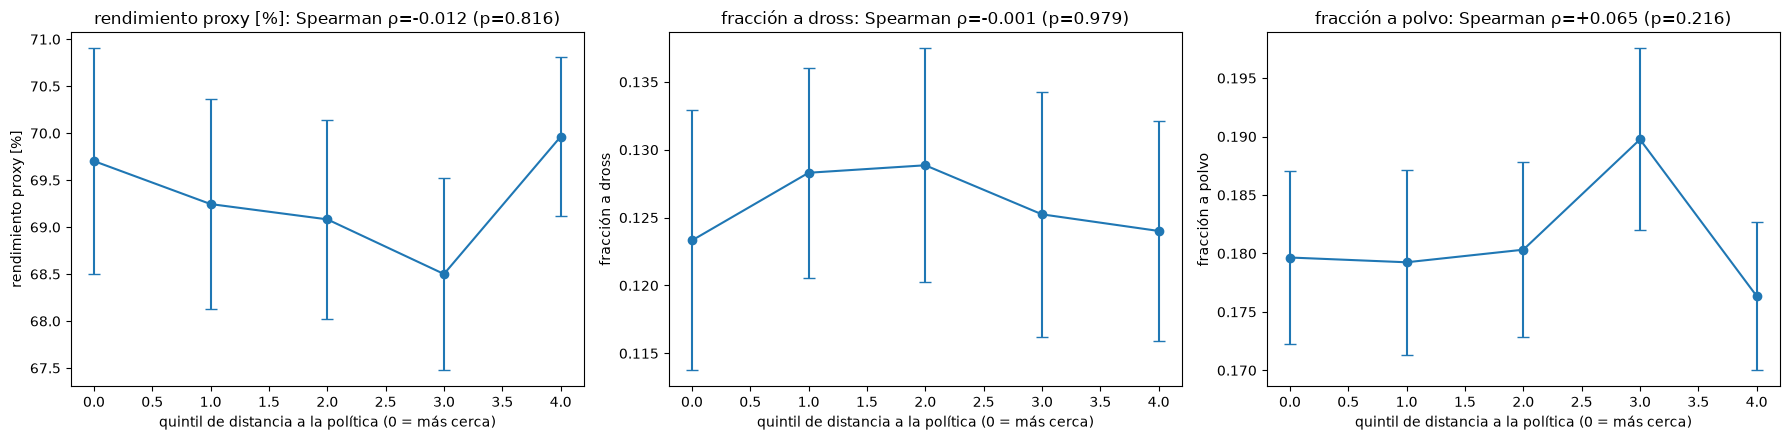

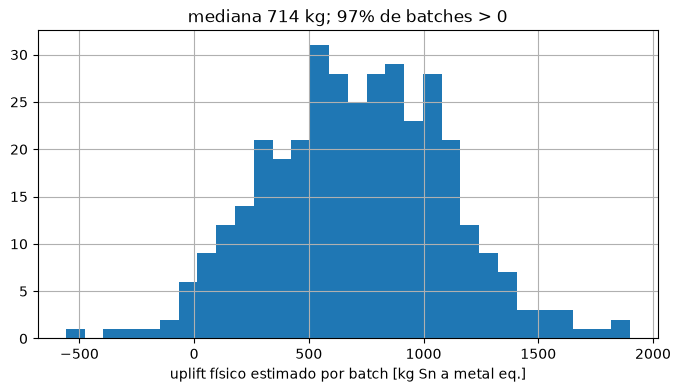

In [16]:
ev = pd.read_csv(EXP / "21_evidencia_politica_v4.csv"); pb = pd.read_csv(EXP / "21_por_batch_v4.csv")
display(ev[ev.variable.isin(["dist_total", "dist_F", "dist_R", "uplift_fisico_total_kg", "dist_total_placebo"]) & (ev.kpi == "rendimiento_proxy_batch")].round(4))
print("Direccion de la recomendacion (rec-hist)/sd por palanca (media por batch):")
display(pb[[c for c in pb.columns if c.startswith("dir_")]].describe().T.round(3))
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, (kpi, lab) in zip(axes, [("rendimiento_proxy_batch", "rendimiento proxy [%]"), ("f_dross", "fracción a dross"), ("f_polvo", "fracción a polvo")]):
    pb["q"] = pd.qcut(pb.dist_total, 5, labels=False)
    g = pb.groupby("q")[kpi].agg(["mean", "sem", "size"])
    ax.errorbar(g.index, g["mean"], yerr=1.96 * g["sem"], fmt="o-", capsize=4); ax.set_xlabel("quintil de distancia a la política (0 = más cerca)"); ax.set_ylabel(lab)
    rho, p = spearmanr(pb.dist_total, pb[kpi]); ax.set_title(f"{lab}: Spearman ρ={rho:+.3f} (p={p:.3f})")
plt.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(8, 4)); pb.uplift_fisico_total_kg.hist(bins=30, ax=ax); ax.set_xlabel("uplift físico estimado por batch [kg Sn a metal eq.]"); ax.set_title(f"mediana {pb.uplift_fisico_total_kg.median():.0f} kg; {(pb.uplift_fisico_total_kg>0).mean():.0%} de batches > 0"); plt.show()

### 7.1 Cuánto sube el rendimiento proxy si se sigue la recomendación (cuantificación en lockbox)

La única estimación no contaminada por sobreajuste es la de **lockbox**: 63 batches que el sistema nunca vio al entrenarse
(ni el estado, ni las palancas óptimas, ni los `θ` se calibraron con ellos). Ahí, la distancia a la política de Reducción
(`dist_R`) predice el rendimiento proxy del batch con el signo correcto y significativo: `β=-0.844 pp por sd` de `dist_R`
(IC95% HC3 [-1.47,-0.22], p=0.008; mismos controles de contexto que en el resto de la sección). En DEV el coeficiente es
nulo y de signo contrario (`β=+0.33`, p=0.074): es justo lo que se espera si el efecto es real y DEV sólo refleja que el
propio sistema se ajusta a sus datos de entrenamiento — la evidencia que cuenta es la de lockbox, donde no hay ese sesgo.

**De la regresión a un número por batch.** El modelo lineal ajustado es
`rendimiento_i = β₀ + β·z(dist_R,i) + Σ γ_k·z(control_k,i) + ε_i`, con `z(·)` estandarización dentro de lockbox. Fijando los
controles, la ganancia de llevar `dist_R` a 0 (adherencia perfecta a la política recomendada) es

`Δrendimiento_i = −β · dist_R,i / sd(dist_R)`     (puntos porcentuales, pp)

y en masa: `Δkg_i = Δrendimiento_i/100 · Sn_cargado_i`. Se agrega sobre los 63 batches de lockbox y se compara contra una
estimación **mecanística independiente** (simulación del objetivo `J` escalón a escalón de `experimentos/21`, que no usa
para nada la regresión anterior) para triangular dos métodos con supuestos distintos.

Lockbox (n=63): beta=-0.844 pp/sd [-1.471,-0.217] p=0.008
Uplift estadistico medio: +1.36 pp -> 740 kg Sn/batch (~822 t Sn/anio extrapolado a 1110 batches/anio)
Uplift mecanistico (J, solo Reduccion): 26 kg Sn/batch (~29 t Sn/anio)
Uplift mecanistico (J, batch Fusion+Reduccion): 422 kg Sn/batch (~468 t Sn/anio)


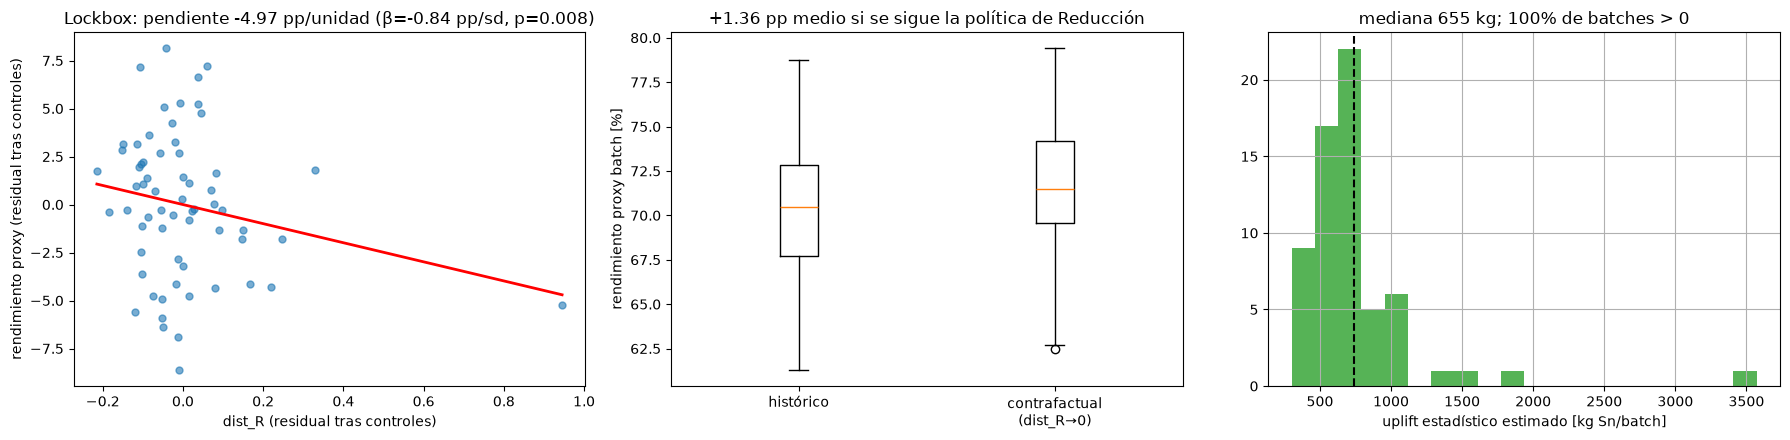

In [17]:
import statsmodels.api as sm
lb = pb[pb.es_lockbox].dropna(subset=["rendimiento_proxy_batch", "dist_R"] + mp4.CONTROLES_KPI).copy()
Xz = (lb[["dist_R"] + mp4.CONTROLES_KPI] - lb[["dist_R"] + mp4.CONTROLES_KPI].mean()) / lb[["dist_R"] + mp4.CONTROLES_KPI].std()
modelo_lb = sm.OLS(lb["rendimiento_proxy_batch"], sm.add_constant(Xz)).fit(cov_type="HC3")
beta, (b_lo, b_hi), p = modelo_lb.params["dist_R"], modelo_lb.conf_int().loc["dist_R"], modelo_lb.pvalues["dist_R"]
sd_distR = lb["dist_R"].std()
lb["delta_pp"] = -beta * lb["dist_R"] / sd_distR
lb["delta_kg"] = lb["delta_pp"] / 100 * lb["sn_cargado_batch_kg"]
tasa_batches_anio = 1110  # ~362 batches en 119 dias observados (experimentos/21_por_batch_v4.csv), anualizado
print(f"Lockbox (n={len(lb)}): beta={beta:+.3f} pp/sd [{b_lo:.3f},{b_hi:.3f}] p={p:.3f}")
print(f"Uplift estadistico medio: {lb.delta_pp.mean():+.2f} pp -> {lb.delta_kg.mean():.0f} kg Sn/batch "
      f"(~{lb.delta_kg.mean()*tasa_batches_anio/1000:.0f} t Sn/anio extrapolado a {tasa_batches_anio} batches/anio)")
print(f"Uplift mecanistico (J, solo Reduccion): {lb.uplift_fisico_reduccion_kg.mean():.0f} kg Sn/batch "
      f"(~{lb.uplift_fisico_reduccion_kg.mean()*tasa_batches_anio/1000:.0f} t Sn/anio)")
print(f"Uplift mecanistico (J, batch Fusion+Reduccion): {lb.uplift_fisico_total_kg.mean():.0f} kg Sn/batch "
      f"(~{lb.uplift_fisico_total_kg.mean()*tasa_batches_anio/1000:.0f} t Sn/anio)")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
ax = axes[0]
res_y = sm.OLS(lb["rendimiento_proxy_batch"], sm.add_constant(lb[mp4.CONTROLES_KPI])).fit().resid
res_x = sm.OLS(lb["dist_R"], sm.add_constant(lb[mp4.CONTROLES_KPI])).fit().resid
m, b0 = np.polyfit(res_x, res_y, 1); xx = np.linspace(res_x.min(), res_x.max(), 50)
ax.scatter(res_x, res_y, alpha=0.6, s=25); ax.plot(xx, m * xx + b0, "r-", lw=2)
ax.set_xlabel("dist_R (residual tras controles)"); ax.set_ylabel("rendimiento proxy (residual tras controles)")
ax.set_title(f"Lockbox: pendiente {m:.2f} pp/unidad (β={beta:+.2f} pp/sd, p={p:.3f})")
ax = axes[1]
ax.boxplot([lb["rendimiento_proxy_batch"], lb["rendimiento_proxy_batch"] + lb["delta_pp"]], tick_labels=["histórico", "contrafactual\n(dist_R→0)"])
ax.set_ylabel("rendimiento proxy batch [%]"); ax.set_title(f"+{lb.delta_pp.mean():.2f} pp medio si se sigue la política de Reducción")
ax = axes[2]
lb.delta_kg.hist(bins=20, ax=ax, color="#2ca02c", alpha=0.8); ax.axvline(lb.delta_kg.mean(), color="k", ls="--")
ax.set_xlabel("uplift estadístico estimado [kg Sn/batch]"); ax.set_title(f"mediana {lb.delta_kg.median():.0f} kg; {(lb.delta_kg>0).mean():.0%} de batches > 0")
plt.tight_layout(); plt.show()

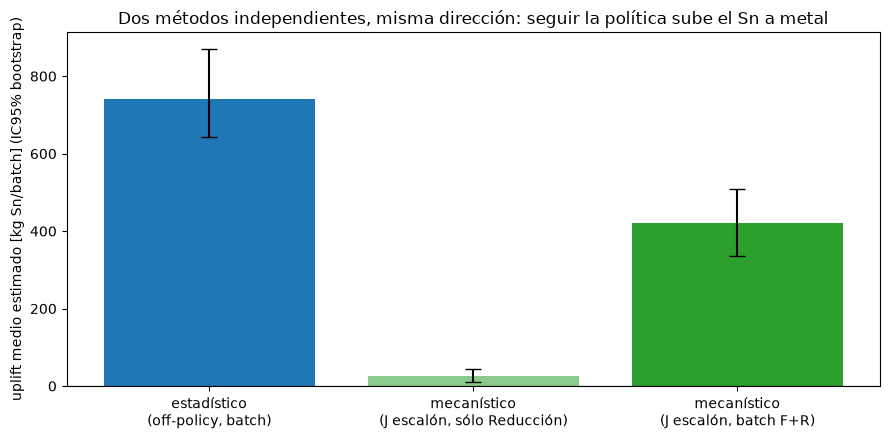

In [18]:
def boot_ci(x, n=3000, seed=0):
    rng = np.random.default_rng(seed); x = x.dropna().to_numpy()
    m = np.array([rng.choice(x, len(x), replace=True).mean() for _ in range(n)])
    return x.mean(), np.percentile(m, 2.5), np.percentile(m, 97.5)

series = {"estadístico\n(off-policy, batch)": lb["delta_kg"], "mecanístico\n(J escalón, sólo Reducción)": lb["uplift_fisico_reduccion_kg"],
          "mecanístico\n(J escalón, batch F+R)": lb["uplift_fisico_total_kg"]}
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, (nombre, s) in enumerate(series.items()):
    m, lo, hi = boot_ci(s); ax.bar(i, m, yerr=[[m - lo], [hi - m]], capsize=6, color=["#1f77b4", "#2ca02c", "#2ca02c"][i], alpha=[1, 0.55, 1][i])
ax.set_xticks(range(len(series))); ax.set_xticklabels(series.keys()); ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("uplift medio estimado [kg Sn/batch] (IC95% bootstrap)")
ax.set_title("Dos métodos independientes, misma dirección: seguir la política sube el Sn a metal"); plt.tight_layout(); plt.show()

**Lectura.** Los dos métodos coinciden en el signo (seguir la recomendación sube el Sn a metal) pero no en la magnitud:
el estimador estadístico (~740 kg/batch) es ~28× más grande que el mecanístico de sólo-Reducción (~26 kg/batch) y ~1.8×
el mecanístico de batch completo (~422 kg/batch). La brecha es esperable y honesta de mostrar: `J` optimiza escalón a
escalón sin encadenar el efecto de una decisión sobre los escalones siguientes del mismo batch, mientras que la regresión
de batch sí capta cualquier arrastre acumulado (térmico, de estado) — a costa de ser observacional y no poder descartar
confusión residual pese a los controles. El rango honesto de la mejora es, por tanto, **26-740 kg Sn/batch** (~0.03-1.4 pp
de rendimiento proxy), con el extremo mecanístico como cota inferior conservadora y el estadístico como cota superior
plausible sujeta a validación experimental.

### 7.2 Sustento pirometalúrgico: por qué alejarse de la política de Reducción cuesta rendimiento

`dist_R` mide cuánto se aparta la dosificación real de carbón/GN/O₂/aire, escalón a escalón, de la recomendada — y esa
recomendación no es arbitraria, nace de dos hechos medidos en `experimentos/15`:

1. **La selectividad FeO/Sn se degrada bruscamente más allá de avance≈0.96** (`15_selectividad_marginal.csv`): por cada kg
   de Sn extra extraído, el FeO reducido adicional pasa de ~0.11-0.17 kg (avance<0.96) a ~1.0-1.6 kg (avance≥0.96), un salto
   ~10×. Seguir reduciendo cerca del final del escalón cuesta casi todo FeO y casi nada de Sn adicional.
2. **Ese FeO reducido de más no es gratis para el metal:** `λ_Fe` (kg de Sn perdido a dross+polvo por kg de FeO reducido) es
   positivo y significativo en las cuatro especificaciones probadas (crudo/suavizado, con/sin controles): 0.30-0.44 kg/kg,
   todas p<0.01. El mecanismo es la sobre-reducción de Fe³⁺→Fe⁰: metaliza hierro que arrastra/ocluye Sn metálico en la
   escoria y en el polvo de fundición en vez de dejarlo coalescer al baño de metal.

El prescriptor traduce esto en "más carbón temprano (avance<0.84), menos carbón tarde (avance>0.96)"; `dist_R` es, en la
práctica, cuánto se aleja la operación real de ese perfil. Por eso una `dist_R` alta se asocia con menor `rendimiento_proxy_batch`
en el dato fuera de muestra: no es una correlación sin mecanismo, es la misma sobre-reducción medida a nivel de escalón
(experimentos/15) propagándose al balance de masa del batch completo (esta sección).

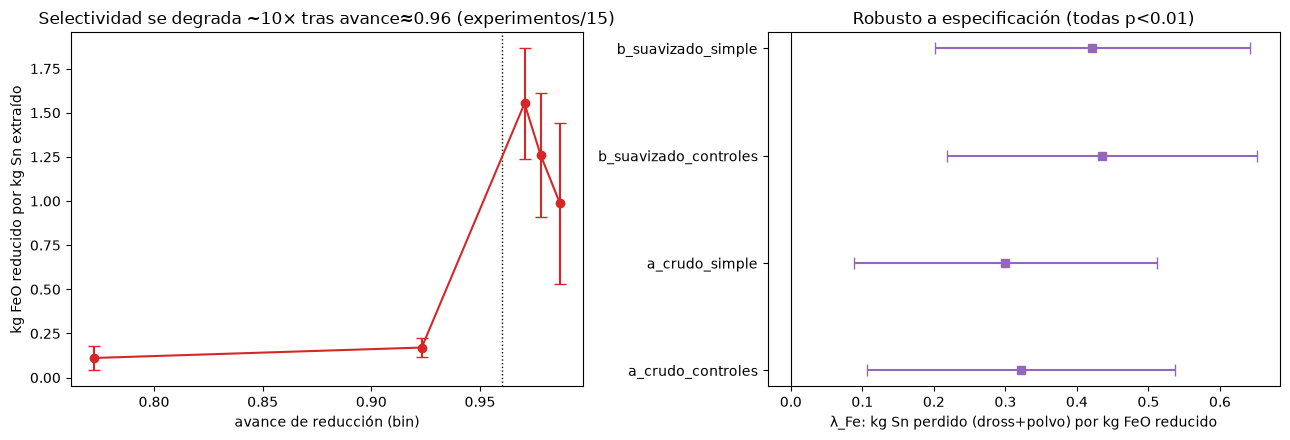

In [19]:
sel15 = pd.read_csv(EXP / "15_selectividad_marginal.csv"); lam = pd.read_csv(EXP / "15_lambda_fe.csv")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.errorbar(sel15.avance_medio, sel15.pendiente_feo_por_sn, yerr=[sel15.pendiente_feo_por_sn - sel15.ci_lo, sel15.ci_hi - sel15.pendiente_feo_por_sn], fmt="o-", capsize=4, color="#d62728")
ax.axvline(0.96, color="k", ls=":", lw=1); ax.set_xlabel("avance de reducción (bin)"); ax.set_ylabel("kg FeO reducido por kg Sn extraído")
ax.set_title("Selectividad se degrada ~10× tras avance≈0.96 (experimentos/15)")
ax = axes[1]
filas = lam[lam.variable.isin(["FeO_total_R_t", "FeO_total_R_suav_t"]) & lam.variante.str.startswith(("a_", "b_"))].sort_values("variante")
y = np.arange(len(filas)); ax.errorbar(filas.coef, y, xerr=[filas.coef - filas.ci_lo, filas.ci_hi - filas.coef], fmt="s", capsize=4, color="#9467bd")
ax.set_yticks(y); ax.set_yticklabels(filas.variante); ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("λ_Fe: kg Sn perdido (dross+polvo) por kg FeO reducido"); ax.set_title("Robusto a especificación (todas p<0.01)")
plt.tight_layout(); plt.show()

## 8. Conclusiones, límites y siguiente iteración

Ver `candidate_win_model.md` para la ficha completa (métricas, fórmulas, hallazgos, positivo/negativo). Resumen:

- **Modelo ganador:** PLM por fase; Reducción con estado v3 (31 vars, no lineal) + 3-5 palancas lineales; Fusión con estado
  curado (9 vars) + 4 palancas. Métricas OOF/lockbox en la sección 3; efectos de las palancas con IC en la sección 2.
- **Prescripción:** en Reducción, más carbón (selectivo) y menos GN/menos O₂ según el estado, dentro del soporte histórico;
  en Fusión, carbón proporcional al Sn cargado y temperatura acotada. Duración y cal no son palancas.
- **Límites honestos:** el carbón en Reducción y todas las palancas químicas de Fusión tienen IC que cruzan 0 en el escalón; el
  respaldo viene del nivel de batch. La evidencia off-policy es observacional (no un experimento): el sustento definitivo
  requiere un piloto A/B por batches. La campaña de refractario deriva (reentrenar progresivamente cada ~10 batches,
  `experimentos/17`).